# Notebook 02 — Baseline radiografías

**Parte 2** del trabajo: correr BLIP base (sin fine-tuning) sobre las radiografías seleccionadas y extraer mapas de cross-attention y Grad-CAM.

**Objetivo:** documentar que BLIP base genera captions genéricos y heatmaps médicamente incoherentes. Este es el punto de partida (baseline) antes del fine-tuning.

**Outputs generados:**
- `outputs/parte2_baseline/captions.json` — índice, caption generado, impression real
- `outputs/parte2_baseline/comparacion_XXXXX.png` — figura cross-att vs grad-cam por imagen

## 0. Configuración global

Cambiar `N_IMAGES` antes de correr en GPU para procesar las 25 imágenes completas.

In [1]:
# ── Variable global: cuántas imágenes procesar ─────────────────────────────
# CPU local: usar 5. GPU (Kaggle/GCP): subir a 25.
N_IMAGES = 1

In [2]:
import torch
print(torch.__version__)
print("xpu disponible:", torch.xpu.is_available())

2.12.0+cu130
xpu disponible: False


## 1. Imports y paths

In [3]:
import json
import sys
from pathlib import Path

import torch
from datasets import load_dataset

# agregar raíz del proyecto al path para imports absolutos desde src/
# En Jupyter, __file__ no existe → usamos cwd() que apunta a notebooks/
ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.models.blip_loader import load_model_and_processor
from src.interpretability.cross_attention import eval_and_extract_cross_att
from src.interpretability.gradcam import compute_gradcam
from src.visualization.heatmap import plot_comparison_heatmaps, save_heatmap_grid

# paths
MODEL_DIR       = ROOT / "models" / "blip_base"
INDICES_PATH    = ROOT / "data" / "visual_test_indices.json"
HF_CACHE_DIR    = ROOT / "data" / "hf_cache"
OUTPUT_DIR      = ROOT / "outputs" / "parte2_baseline"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"ROOT          : {ROOT}")
print(f"MODEL_DIR     : {MODEL_DIR}  (existe: {MODEL_DIR.exists()})")
print(f"INDICES_PATH  : {INDICES_PATH}  (existe: {INDICES_PATH.exists()})")
print(f"Output dir    : {OUTPUT_DIR}")
print(f"Device        : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print(f"N_IMAGES      : {N_IMAGES}")

ROOT          : /home/felisl/Escritorio/feli/vision/segunda_parte/tp_final/image-captioning
MODEL_DIR     : /home/felisl/Escritorio/feli/vision/segunda_parte/tp_final/image-captioning/models/blip_base  (existe: True)
INDICES_PATH  : /home/felisl/Escritorio/feli/vision/segunda_parte/tp_final/image-captioning/data/visual_test_indices.json  (existe: True)
Output dir    : /home/felisl/Escritorio/feli/vision/segunda_parte/tp_final/image-captioning/outputs/parte2_baseline
Device        : CPU
N_IMAGES      : 1


## 2. Cargar modelo y dataset

In [4]:
model, processor = load_model_and_processor(model_dir=MODEL_DIR)
device = next(model.parameters()).device
print(f"Modelo cargado en: {device}")

Loading weights:   0%|          | 0/471 [00:00<?, ?it/s]

Modelo cargado en: cpu


In [5]:
import os
os.environ["HF_DATASETS_CACHE"] = str(HF_CACHE_DIR)

ds = load_dataset("itsanmolgupta/mimic-cxr-dataset", cache_dir=str(HF_CACHE_DIR))
train_split = ds["train"]
print(f"Dataset cargado: {len(train_split)} filas")

Dataset cargado: 30633 filas


## 3. Seleccionar imágenes

In [6]:
with open(INDICES_PATH) as f:
    all_indices = json.load(f)

selected_indices = all_indices[:N_IMAGES]
print(f"Índices a procesar ({N_IMAGES}/{len(all_indices)}): {selected_indices}")

Índices a procesar (1/25): [731]


In [7]:
# cargar imágenes e impressions correspondientes
images = []
impressions = []

for idx in selected_indices:
    row = train_split[idx]
    images.append(row["image"].convert("RGB"))
    impressions.append(row["impression"] or "")

print(f"Imágenes cargadas: {len(images)}")
print(f"Tamaño de muestra: {images[0].size}")
print(f"Impression [0]: {impressions[0][:120]}...")

Imágenes cargadas: 1
Tamaño de muestra: (512, 512)
Impression [0]: Acute asymmetric pulmonary edema, right greater than left, more likely than mild edema and concurrent right pneumonia....


### Vista previa de las imágenes seleccionadas

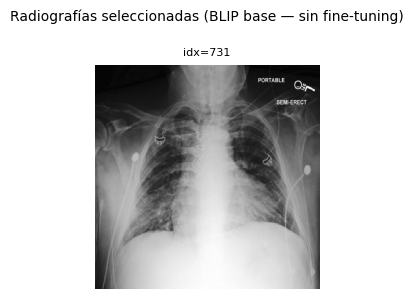

In [8]:
import matplotlib.pyplot as plt

n_cols = min(N_IMAGES, 5)
n_rows = (N_IMAGES + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3), dpi=100)

import numpy as np
axes = np.array(axes).flatten()

for i, (img, idx) in enumerate(zip(images, selected_indices)):
    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(f"idx={idx}", fontsize=8)
    axes[i].axis("off")

for j in range(N_IMAGES, len(axes)):
    axes[j].axis("off")

plt.suptitle("Radiografías seleccionadas (BLIP base — sin fine-tuning)", fontsize=10)
plt.tight_layout()
plt.show()

## 4. Cross-attention — extracción por imagen

In [9]:
from tqdm.notebook import tqdm

cross_att_results = []

model.eval()
for img in tqdm(images, desc="Cross-attention"):
    inputs = processor(images=img, return_tensors="pt").to(str(device))
    result = eval_and_extract_cross_att(model, processor, inputs, num_batch=1)
    cross_att_results.append(result[0])  # result es lista de 1 elemento

print("\nEjemplo caption [0]:", cross_att_results[0]["caption"])
print("Palabras [0]:", [w for w, _ in cross_att_results[0]["maps"]])

Cross-attention:   0%|          | 0/1 [00:00<?, ?it/s]


Ejemplo caption [0]: a chest xray with a large , white chest
Palabras [0]: ['a', 'chest', 'xray', 'with', 'a', 'large', ',', 'white', 'chest']


## 5. Grad-CAM — extracción por imagen

> ⚠️ En CPU esto puede tardar ~5–10 min por imagen. En GPU es ~10-20 seg.

In [10]:
gradcam_results = []

for i, img in enumerate(tqdm(images, desc="Grad-CAM")):
    result = compute_gradcam(model, processor, [img], device=str(device))
    gradcam_results.append(result[0])  # result es lista de 1 elemento
    print(f"  [{i}] caption: {result[0]['caption']}")

print("\nGrad-CAM listo.")

Grad-CAM:   0%|          | 0/1 [00:00<?, ?it/s]

  [0] caption: a chest xray with a large , white chest

Grad-CAM listo.


## 6. Verificación rápida — primera imagen

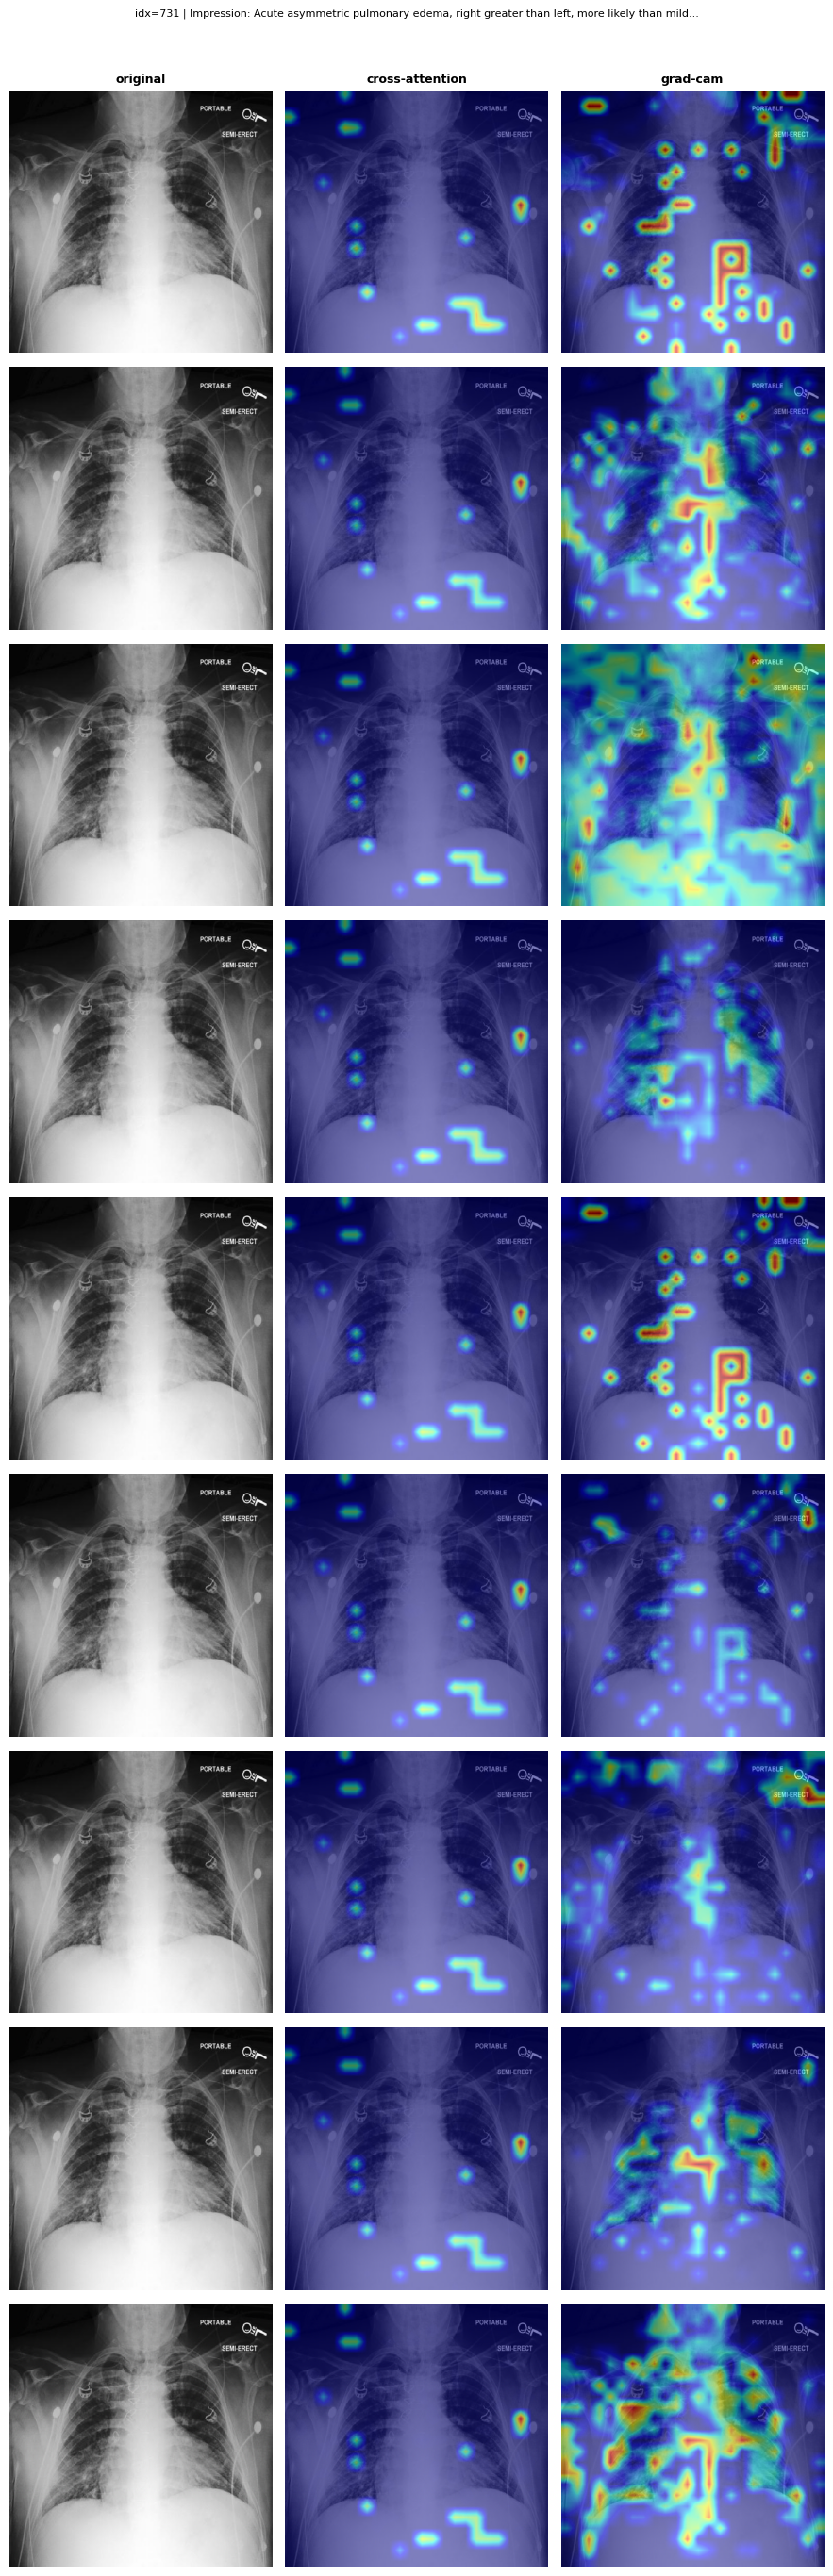

In [11]:
fig = plot_comparison_heatmaps(
    image=images[0],
    cross_att_results=cross_att_results[0],
    gradcam_results=gradcam_results[0],
    idx=0,
    dpi=100,
)
plt.suptitle(
    f"idx={selected_indices[0]} | Impression: {impressions[0][:80]}...",
    fontsize=8, y=1.01,
)
plt.tight_layout()
plt.show()

## 7. Guardar outputs a disco

In [12]:
# 7a. captions.json
captions_data = [
    {
        "idx": int(selected_indices[i]),
        "caption_generado": cross_att_results[i]["caption"],
        "impression_real": impressions[i],
    }
    for i in range(N_IMAGES)
]

captions_path = OUTPUT_DIR / "captions.json"
with open(captions_path, "w", encoding="utf-8") as f:
    json.dump(captions_data, f, ensure_ascii=False, indent=2)

print(f"captions.json guardado en: {captions_path}")

captions.json guardado en: /home/felisl/Escritorio/feli/vision/segunda_parte/tp_final/image-captioning/outputs/parte2_baseline/captions.json


In [13]:
# 7b. figuras de comparación cross-att vs grad-cam (una por imagen)
for i in range(N_IMAGES):
    idx = selected_indices[i]
    out_path = OUTPUT_DIR / f"comparacion_{idx:05d}.png"

    fig = plot_comparison_heatmaps(
        image=images[i],
        cross_att_results=cross_att_results[i],
        gradcam_results=gradcam_results[i],
        idx=0,
        dpi=200,
    )
    fig.suptitle(
        f"idx={idx} | {impressions[i][:80]}",
        fontsize=7, y=1.005,
    )

    fig.savefig(out_path, bbox_inches="tight", dpi=200)
    plt.close(fig)
    print(f"  Guardado: {out_path.name}")

print(f"\nFiguras guardadas en: {OUTPUT_DIR}")

  Guardado: comparacion_00731.png

Figuras guardadas en: /home/felisl/Escritorio/feli/vision/segunda_parte/tp_final/image-captioning/outputs/parte2_baseline


## 8. Resumen

In [14]:
print("=" * 60)
print("RESUMEN — Parte 2: Baseline radiografías")
print("=" * 60)
print(f"Imágenes procesadas : {N_IMAGES} / {len(all_indices)}")
print(f"Índices usados      : {selected_indices}")
print()
print("Captions generados por BLIP base:")
for item in captions_data:
    print(f"  [{item['idx']:5d}] BLIP    : {item['caption_generado']}")
    print(f"         Impression: {item['impression_real'][:80]}")
    print()
print(f"Outputs en: {OUTPUT_DIR}")
print("  - captions.json")
for i in range(N_IMAGES):
    print(f"  - comparacion_{selected_indices[i]:05d}.png")

RESUMEN — Parte 2: Baseline radiografías
Imágenes procesadas : 1 / 25
Índices usados      : [731]

Captions generados por BLIP base:
  [  731] BLIP    : a chest xray with a large , white chest
         Impression: Acute asymmetric pulmonary edema, right greater than left, more likely than mild

Outputs en: /home/felisl/Escritorio/feli/vision/segunda_parte/tp_final/image-captioning/outputs/parte2_baseline
  - captions.json
  - comparacion_00731.png
